## Task 4: Data Visualization
Goal:
    Create visual representations to communicate insights clearly.
Key Requirements:
    • Create charts and graphs
    • Choose appropriate visual types
    • Highlight key insights
Key Skills:
    Data visualization, storytelling with data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams.update({
    "figure.facecolor": "#f5f5f0",
    "axes.facecolor":   "#f5f5f0",
    "axes.edgecolor":   "#4a6741",
    "axes.labelcolor":  "#3a5232",
    "xtick.color":      "#3a5232",
    "ytick.color":      "#3a5232",
    "text.color":       "#3a5232",
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})
GREEN  = "#4a6741"
TEAL   = "#5b9b8a"
ORANGE = "#e07b39"
PALETTE = [GREEN, ORANGE, TEAL, "#8fbc8f", "#d4a76a"]
sns.set_palette(PALETTE)

In [3]:
df_raw = pd.read_csv("Titanic-Dataset.csv")
df = df_raw.copy()

In [4]:
# 1. Missing values BEFORE
print(f"\n Missing values BEFORE cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


 Missing values BEFORE cleaning:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [5]:
# 2. Drop Cabin (>77% missing — not salvageable)
df.drop(columns=["Cabin"], inplace=True)
print("\nDropped 'Cabin' column (77% missing, not recoverable)")


Dropped 'Cabin' column (77% missing, not recoverable)


In [6]:
# 3. Fill Age with median (robust to outliers)
age_median = df["Age"].median()
df["Age"].fillna(age_median, inplace=True)
print(f"Filled {df_raw['Age'].isnull().sum()} missing 'Age' values with median ({age_median})")

Filled 177 missing 'Age' values with median (28.0)


In [7]:
# 4. Fill Embarked with mode (only 2 missing)
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"].fillna(embarked_mode, inplace=True)
print(f"Filled 2 missing 'Embarked' values with mode ('{embarked_mode}')")

Filled 2 missing 'Embarked' values with mode ('S')


In [8]:
# 5. Remove duplicates
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {dupes_before}")

Duplicates removed: 0


In [9]:
# 6. Feature engineering — extract Title from Name
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")
df["Title"] = df["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"],
    "Rare"
)
df["Title"] = df["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
print("Extracted 'Title' feature from Name column")

Extracted 'Title' feature from Name column


In [10]:
# 7. Create FamilySize
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
print("Created 'FamilySize' = SibSp + Parch + 1")

Created 'FamilySize' = SibSp + Parch + 1


In [11]:
# 8. Create IsAlone
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
print("Created 'IsAlone' flag")

Created 'IsAlone' flag


In [12]:
# 9. Encode categoricals
df["Sex_enc"]      = LabelEncoder().fit_transform(df["Sex"])
df["Embarked_enc"] = LabelEncoder().fit_transform(df["Embarked"])
df["Title_enc"]    = LabelEncoder().fit_transform(df["Title"])
print("Label-encoded: Sex, Embarked, Title")

Label-encoded: Sex, Embarked, Title


In [13]:
# 10. Drop columns not needed for modelling
df.drop(columns=["PassengerId","Name","Ticket"], inplace=True)

In [14]:
print(f"\nMissing values AFTER cleaning: {df.isnull().sum().sum()} total")
print(f"Final dataset shape: {df.shape}")
print(f"\nSample cleaned rows:")
print(df.head(3).to_string())


Missing values AFTER cleaning: 0 total
Final dataset shape: (891, 14)

Sample cleaned rows:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked Title  FamilySize  IsAlone  Sex_enc  Embarked_enc  Title_enc
0         0       3    male  22.0      1      0   7.2500        S    Mr           2        0        1             2          2
1         1       1  female  38.0      1      0  71.2833        C   Mrs           2        0        0             0          3
2         1       3  female  26.0      0      0   7.9250        S  Miss           1        1        0             2          1


In [15]:
survival_rate = df["Survived"].mean() * 100
print(f"\nOverall Survival Rate: {survival_rate:.1f}%")


Overall Survival Rate: 38.4%


In [16]:
print("\n── Survival by Gender ───────────────────────────────────")
print(df.groupby("Sex")["Survived"].agg(["mean","count","sum"])
       .rename(columns={"mean":"Rate","count":"Total","sum":"Survived"})
       .assign(Rate=lambda x: (x["Rate"]*100).round(1))
       .to_string())



── Survival by Gender ───────────────────────────────────
        Rate  Total  Survived
Sex                          
female  74.2    314       233
male    18.9    577       109


In [17]:
print("\n── Survival by Passenger Class ──────────────────────────")
print(df.groupby("Pclass")["Survived"].agg(["mean","count","sum"])
       .rename(columns={"mean":"Rate","count":"Total","sum":"Survived"})
       .assign(Rate=lambda x: (x["Rate"]*100).round(1))
       .to_string())


── Survival by Passenger Class ──────────────────────────
        Rate  Total  Survived
Pclass                       
1       63.0    216       136
2       47.3    184        87
3       24.2    491       119


In [18]:
print("\n── Survival by Title ────────────────────────────────────")
print(df.groupby("Title")["Survived"].agg(["mean","count"])
       .rename(columns={"mean":"Rate","count":"Total"})
       .assign(Rate=lambda x: (x["Rate"]*100).round(1))
       .sort_values("Rate", ascending=False)
       .to_string())


── Survival by Title ────────────────────────────────────
               Rate  Total
Title                     
the Countess  100.0      1
Mrs            79.4    126
Miss           70.3    185
Master         57.5     40
Rare           31.8     22
Mr             15.7    517


In [19]:
print("\n── Age Statistics by Survival ───────────────────────────")
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

# Survival rate within each age group
print(
    df.groupby("AgeGroup")["Survived"]
      .mean()
      .round(3)
      .to_string()
)


── Age Statistics by Survival ───────────────────────────
AgeGroup
Child          0.580
Teen           0.429
Young Adult    0.353
Adult          0.400
Senior         0.227


In [20]:
print("\n── Fare Statistics by Class ─────────────────────────────")
print(df.groupby("Pclass")["Fare"].describe().round(2).to_string())


── Fare Statistics by Class ─────────────────────────────
        count   mean    std  min    25%    50%   75%     max
Pclass                                                      
1       216.0  84.15  78.38  0.0  30.92  60.29  93.5  512.33
2       184.0  20.66  13.42  0.0  13.00  14.25  26.0   73.50
3       491.0  13.68  11.78  0.0   7.75   8.05  15.5   69.55


In [21]:
print("\n── Outlier Check (IQR method) ───────────────────────────")
for col in ["Age","Fare","FamilySize"]:
    Q1, Q3 = df[col].quantile([0.25,0.75])
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f"  {col:<14}: {outliers} outliers detected")


── Outlier Check (IQR method) ───────────────────────────
  Age           : 66 outliers detected
  Fare          : 116 outliers detected
  FamilySize    : 91 outliers detected



════════════════════════════════════════════════════════════
  TASK 4 — DATA VISUALIZATION  (saving figure...)
════════════════════════════════════════════════════════════


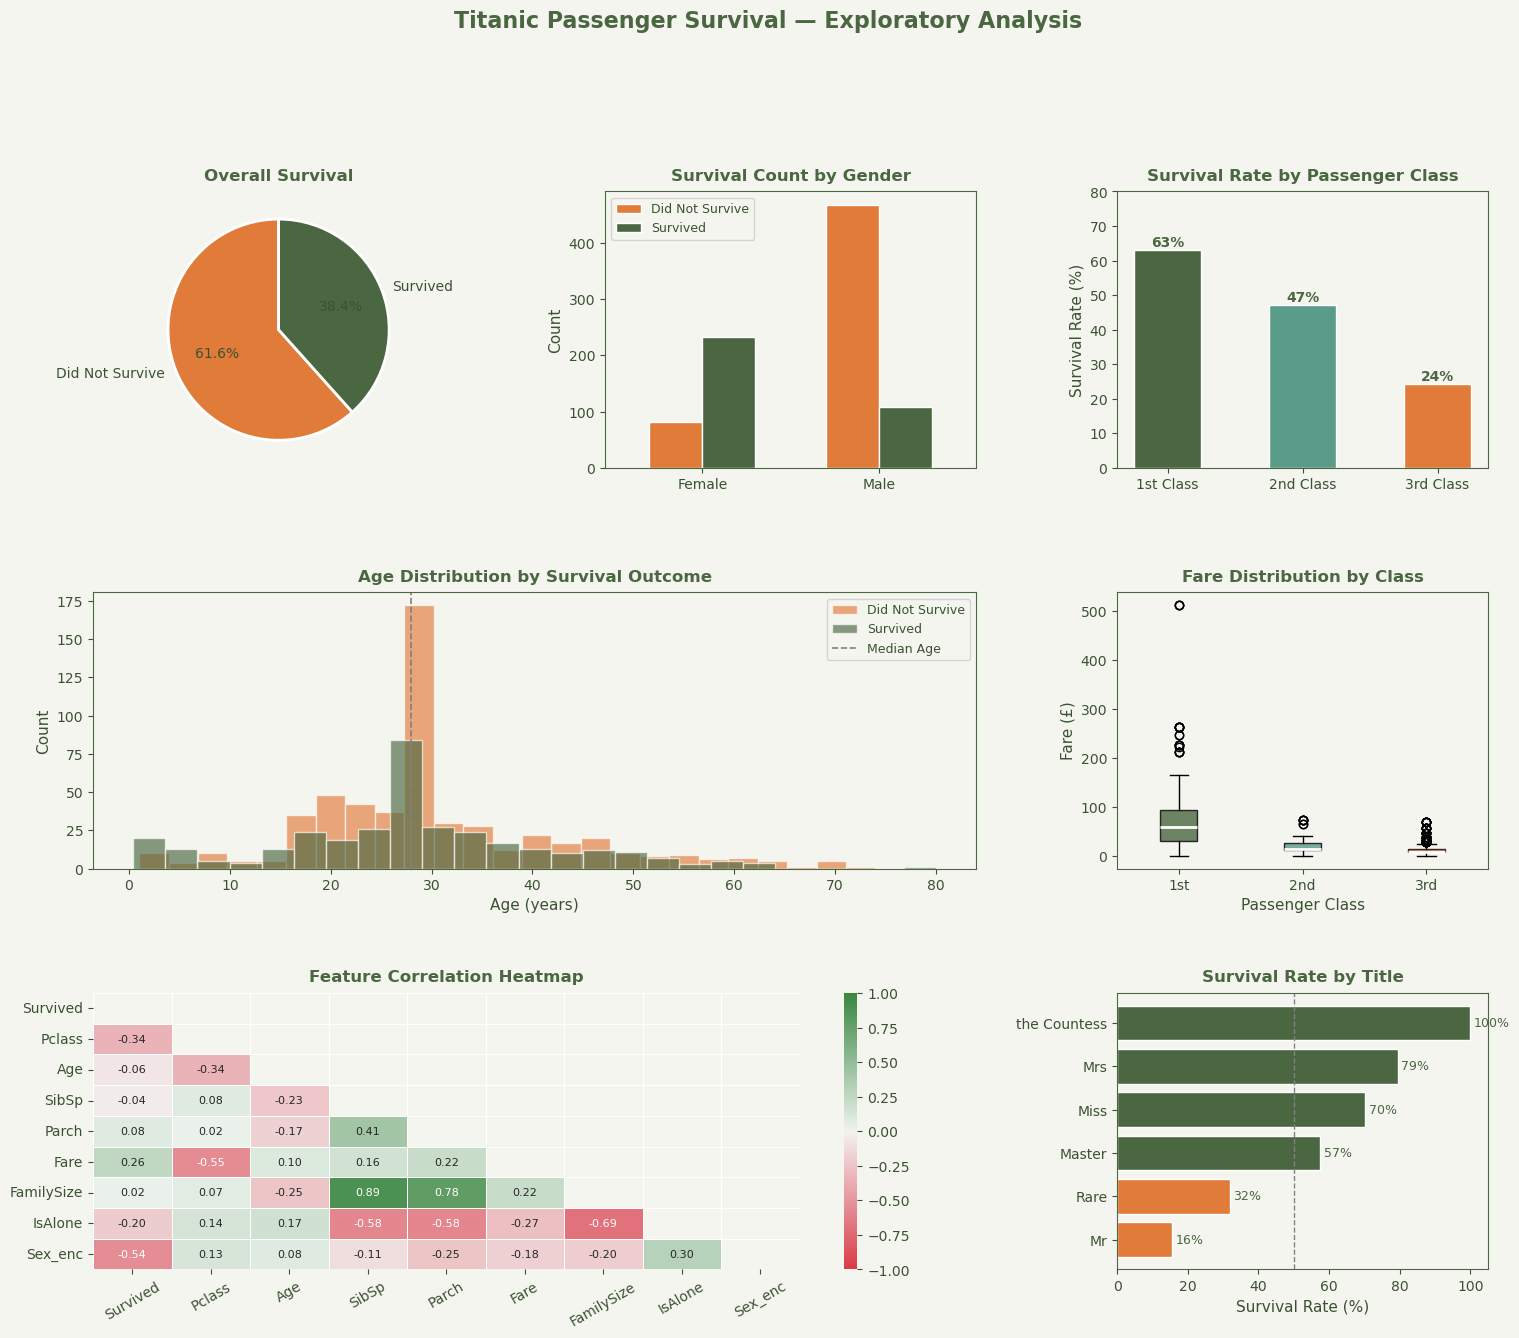

  ✅ Saved: task4_visualizations.png


In [32]:
# ══════════════════════════════════════════════════════════
#  TASK 4 — DATA VISUALIZATION
# ══════════════════════════════════════════════════════════

print("\n" + "═"*60)
print("  TASK 4 — DATA VISUALIZATION  (saving figure...)")
print("═"*60)

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#f5f5f0")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

title_style  = dict(fontsize=12, fontweight="bold", color=GREEN, pad=8)
suptitle_cfg = dict(fontsize=16, fontweight="bold", color=GREEN, y=1.01)

fig.suptitle("Titanic Passenger Survival — Exploratory Analysis", **suptitle_cfg)

# ── 1. Overall Survival Pie ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = df["Survived"].value_counts()

ax1.pie(
    counts,
    labels=["Did Not Survive", "Survived"],
    colors=[ORANGE, GREEN],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
ax1.set_title("Overall Survival", **title_style)

# ── 2. Survival by Gender ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
surv_sex = df.groupby(["Sex", "Survived"]).size().unstack()

surv_sex.plot(
    kind="bar",
    ax=ax2,
    color=[ORANGE, GREEN],
    edgecolor="white",
    width=0.6
)

ax2.set_title("Survival Count by Gender", **title_style)
ax2.set_xlabel("")
ax2.set_xticklabels(["Female", "Male"], rotation=0)
ax2.legend(["Did Not Survive", "Survived"], fontsize=9)
ax2.set_ylabel("Count")

# ── 3. Survival by Pclass ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

surv_class = df.groupby("Pclass")["Survived"].mean() * 100

bars = ax3.bar(
    ["1st Class", "2nd Class", "3rd Class"],
    surv_class.values,
    color=[GREEN, TEAL, ORANGE],
    edgecolor="white",
    width=0.5
)

for bar, val in zip(bars, surv_class.values):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{val:.0f}%",
        ha="center",
        fontsize=10,
        color=GREEN,
        fontweight="bold"
    )

ax3.set_title("Survival Rate by Passenger Class", **title_style)
ax3.set_ylabel("Survival Rate (%)")
ax3.set_ylim(0, 80)

# ── 4. Age Distribution by Survival ─────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])

for survived, label, color in [
    (0, "Did Not Survive", ORANGE),
    (1, "Survived", GREEN)
]:
    subset = df[df["Survived"] == survived]["Age"]
    ax4.hist(subset, bins=25, alpha=0.65, label=label,
             color=color, edgecolor="white")

ax4.set_title("Age Distribution by Survival Outcome", **title_style)
ax4.set_xlabel("Age (years)")
ax4.set_ylabel("Count")

ax4.axvline(
    df["Age"].median(),
    color="grey",
    linestyle="--",
    linewidth=1.2,
    label="Median Age"
)

ax4.legend(fontsize=9)

# ── 5. Fare Boxplot by Class ────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])

data_by_class = [df[df["Pclass"] == c]["Fare"].values for c in [1, 2, 3]]

bp = ax5.boxplot(
    data_by_class,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2)
)

for patch, color in zip(bp["boxes"], [GREEN, TEAL, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax5.set_title("Fare Distribution by Class", **title_style)
ax5.set_xticklabels(["1st", "2nd", "3rd"])
ax5.set_xlabel("Passenger Class")
ax5.set_ylabel("Fare (£)")

# ── 6. Heatmap ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:2])

numeric_cols = [
    "Survived", "Pclass", "Age", "SibSp",
    "Parch", "Fare", "FamilySize", "IsAlone", "Sex_enc"
]

corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(10, 130, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    annot=True,
    fmt=".2f",
    ax=ax6,
    linewidths=0.5,
    annot_kws={"size": 8}
)

ax6.set_title("Feature Correlation Heatmap", **title_style)
ax6.tick_params(axis="x", rotation=30)

# ── 7. Survival by Title ─────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])

title_surv = df.groupby("Title")["Survived"].mean().sort_values() * 100
colors_title = [GREEN if v >= 50 else ORANGE for v in title_surv.values]

bars2 = ax7.barh(
    title_surv.index,
    title_surv.values,
    color=colors_title,
    edgecolor="white"
)

for bar, val in zip(bars2, title_surv.values):
    ax7.text(
        val + 1,
        bar.get_y() + bar.get_height()/2,
        f"{val:.0f}%",
        va="center",
        fontsize=9,
        color=GREEN
    )

ax7.set_title("Survival Rate by Title", **title_style)
ax7.set_xlabel("Survival Rate (%)")
ax7.axvline(50, color="grey", linestyle="--", linewidth=1)

# ══════════════════════════════════════════════════════════
# SAVE FIRST (IMPORTANT FIX)
# ══════════════════════════════════════════════════════════

fig.canvas.draw()

fig.savefig(
    "./task4_visualizations.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#f5f5f0"
)

plt.show()
plt.close(fig)

print("  ✅ Saved: task4_visualizations.png")